In [ ]:
"""
Class 30. Advanced LLMs

Objectives:
1. Zero-shot inference using pre-trained models.
2. Zero-shot inference using heavy General Purpose LLMs using Groq API.
3. Understanding parameter efficient fine-tuning (PEFT).
"""

In [1]:
""" We can use a model on a custom dataset in the following ways:
1. Train the model from scratch using the training dataset. (Training)
2. Fine tune the pretrained model on the training dataset. (Fine-tuning)
3. Fine tuning a pretrained model using a very small subset of the training dataset. (Few shot learning)
4. Use a pretrained model using any fine-tuning. (Zero-shot learning)
"""

from transformers import pipeline

classifier = pipeline(
    task='zero-shot-image-classification',
    model='openai/clip-vit-base-patch32'
)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

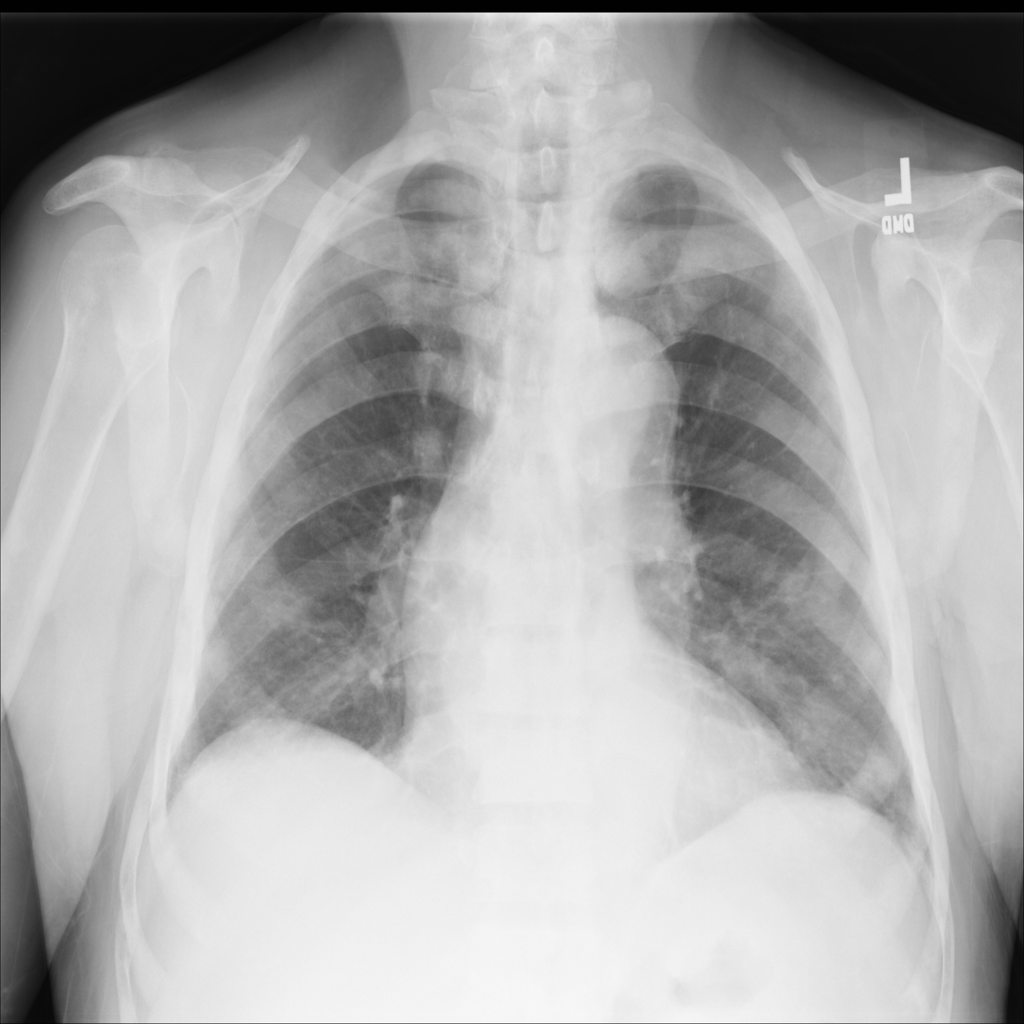

In [14]:
from PIL import Image

image_path = r"C:\Users\ASUS\Downloads\00000011_001.png"
image = Image.open(image_path)

display(image)

In [15]:
candidate_labels = [
    "Atelectasis",
    "Consolidation",
    "Infiltration",
    "Pneumothorax",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Effusion",
    "Pneumonia",
    "Pleural_thickening",
    "Cardiomegaly",
    "Nodule Mass",
    "Hernia"
]

In [16]:
predictions = classifier(
    image, candidate_labels=candidate_labels
)

for pred in predictions:
    print(f"Pathology: {pred['label']} > Confidence: {pred['score']}")

Pathology: Pneumothorax > Confidence: 0.8232967853546143
Pathology: Pneumonia > Confidence: 0.09800579398870468
Pathology: Pleural_thickening > Confidence: 0.032361503690481186
Pathology: Cardiomegaly > Confidence: 0.03181084617972374
Pathology: Emphysema > Confidence: 0.005928564351052046
Pathology: Hernia > Confidence: 0.0036965380422770977
Pathology: Fibrosis > Confidence: 0.0022512166760861874
Pathology: Effusion > Confidence: 0.001003497396595776
Pathology: Nodule Mass > Confidence: 0.0008364057284779847
Pathology: Atelectasis > Confidence: 0.0006404364248737693
Pathology: Edema > Confidence: 0.00014368370466399938
Pathology: Consolidation > Confidence: 2.0440149455680512e-05
Pathology: Infiltration > Confidence: 4.337779500929173e-06


In [19]:
""" Zero shot text classification
"""

detector = pipeline(
    task="zero-shot-object-detection",
    model="google/owlvit-base-patch32"
)

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

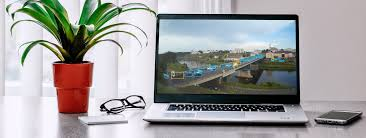

In [20]:
image_path = r"C:\Users\ASUS\Downloads\od.jpeg"
image = Image.open(image_path)

display(image)

In [28]:
candidate_labels = [
    "reading glass",
    "laptop",
    'phone',
]

predictions = detector(image, candidate_labels=candidate_labels)

In [29]:
predictions

[{'score': 0.24023009836673737,
  'label': 'laptop',
  'box': {'xmin': 144, 'ymin': 11, 'xmax': 315, 'ymax': 125}}]

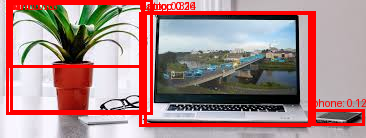

In [30]:
from PIL import Image, ImageDraw, ImageFont
# 4. Initialize drawing context on the image
draw = ImageDraw.Draw(image)

# Optional: Try to load a default font for labels, fallback if unavailable
try:
    font = ImageFont.load_default()
except IOError:
    font = None

# 5. Loop through predictions and draw boxes
for pred in predictions:
    # Only plot confident detections (e.g., score > 0.10)
    if pred["score"] > 0.10:
        box = pred["box"]
        label = pred["label"]
        score = pred["score"]
        
        # Extract coordinates
        xmin, ymin, xmax, ymax = box["xmin"], box["ymin"], box["xmax"], box["ymax"]
        
        # Draw the bounding box rectangle (red color, width of 3 pixels)
        draw.rectangle([(xmin, ymin), (xmax, ymax)], outline="red", width=3)
        
        # Draw the text label and score just above the box
        text = f"{label}: {score:.2f}"
        draw.text((xmin, max(0, ymin - 12)), text, fill="red", font=font)

# 6. Display the final image with boxes in your notebook
display(image)

In [ ]:
""" Zero shot inference for heavy models using Groq API
"""